In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

In [3]:
BASE_PATH = "/content/drive/MyDrive/electricity-load-system"

file_path = f"{BASE_PATH}/data/processed/daily_consumption.csv"

df = pd.read_csv(file_path, parse_dates=["datetime"])
df.head()

,datetime,Global_active_power
0,2006-12-16,3.053475
1,2006-12-17,2.354486
2,2006-12-18,1.530435
3,2006-12-19,1.157079
4,2006-12-20,1.545658


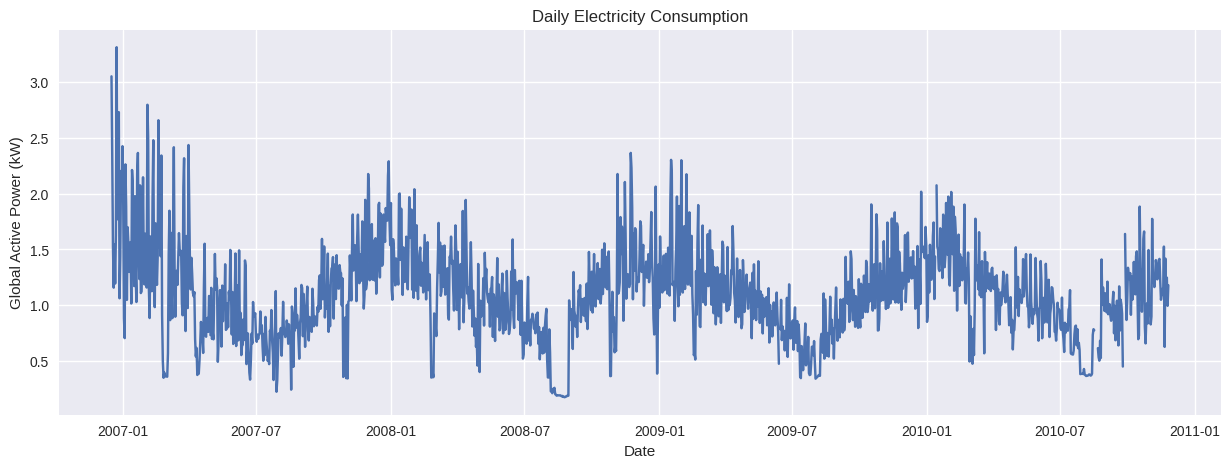

In [4]:
plt.figure(figsize=(15,5))
plt.plot(df["datetime"], df["Global_active_power"])
plt.title("Daily Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.show()

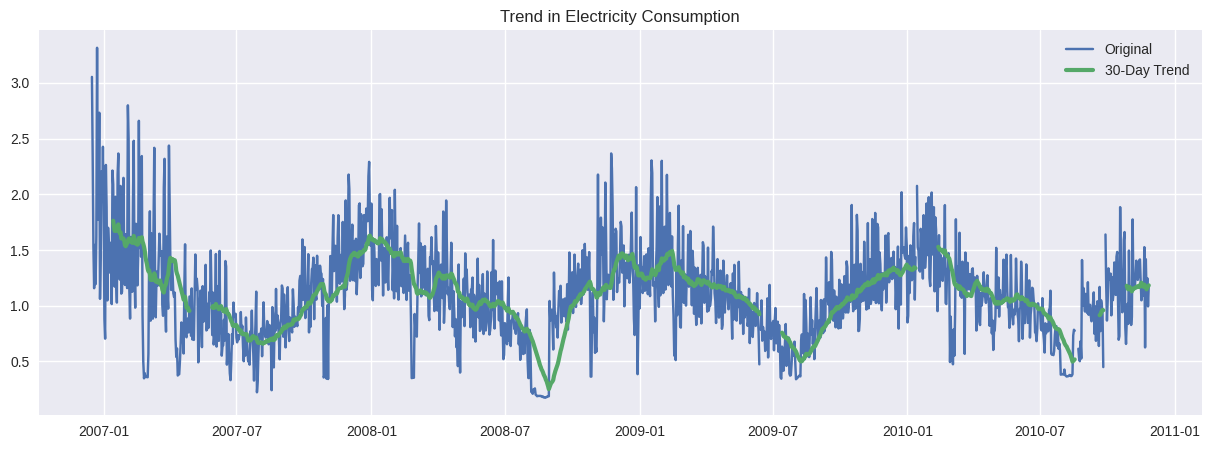

In [5]:
df["trend_30"] = df["Global_active_power"].rolling(window=30).mean()

plt.figure(figsize=(15,5))
plt.plot(df["datetime"], df["Global_active_power"], label="Original")
plt.plot(df["datetime"], df["trend_30"], label="30-Day Trend", linewidth=3)
plt.legend()
plt.title("Trend in Electricity Consumption")
plt.show()

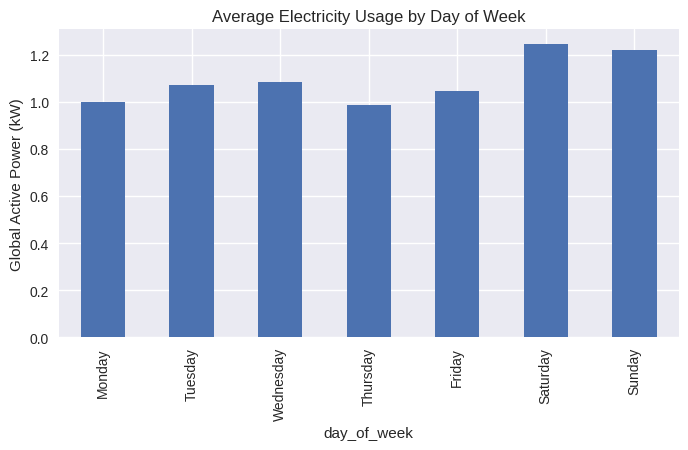

In [6]:
df["day_of_week"] = df["datetime"].dt.day_name()

weekly_avg = df.groupby("day_of_week")["Global_active_power"].mean()

weekly_avg = weekly_avg.reindex([
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
])

plt.figure(figsize=(8,4))
weekly_avg.plot(kind="bar")
plt.title("Average Electricity Usage by Day of Week")
plt.ylabel("Global Active Power (kW)")
plt.show()

In [7]:
df["rolling_mean_7"] = df["Global_active_power"].rolling(window=7).mean()
df["rolling_std_7"] = df["Global_active_power"].rolling(window=7).std()

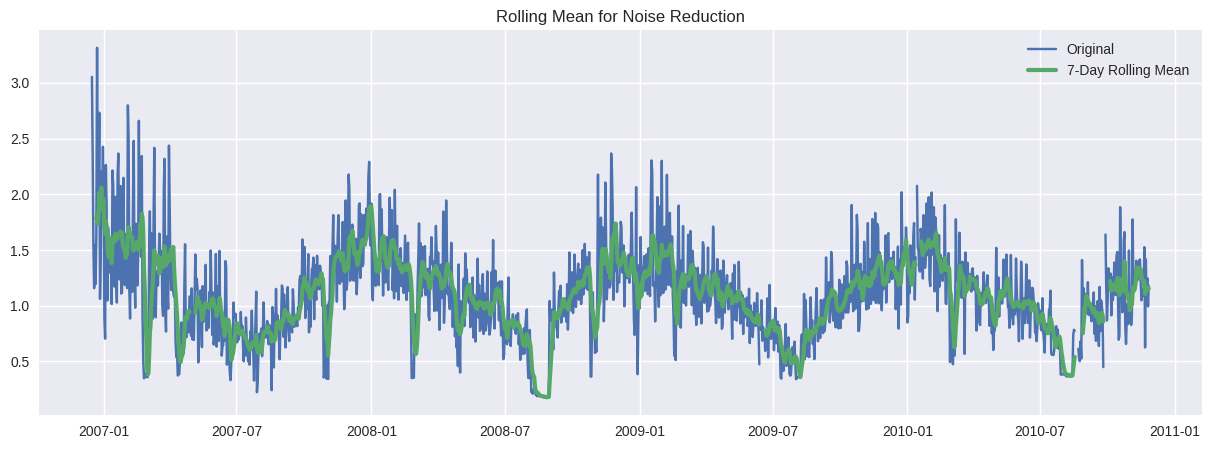

In [8]:
plt.figure(figsize=(15,5))
plt.plot(df["datetime"], df["Global_active_power"], label="Original")
plt.plot(df["datetime"], df["rolling_mean_7"], label="7-Day Rolling Mean", linewidth=3)
plt.legend()
plt.title("Rolling Mean for Noise Reduction")
plt.show()

In [9]:
df["z_score"] = (
    (df["Global_active_power"] - df["rolling_mean_7"]) /
    df["rolling_std_7"]
)

df["anomaly"] = df["z_score"].abs() > 2.5

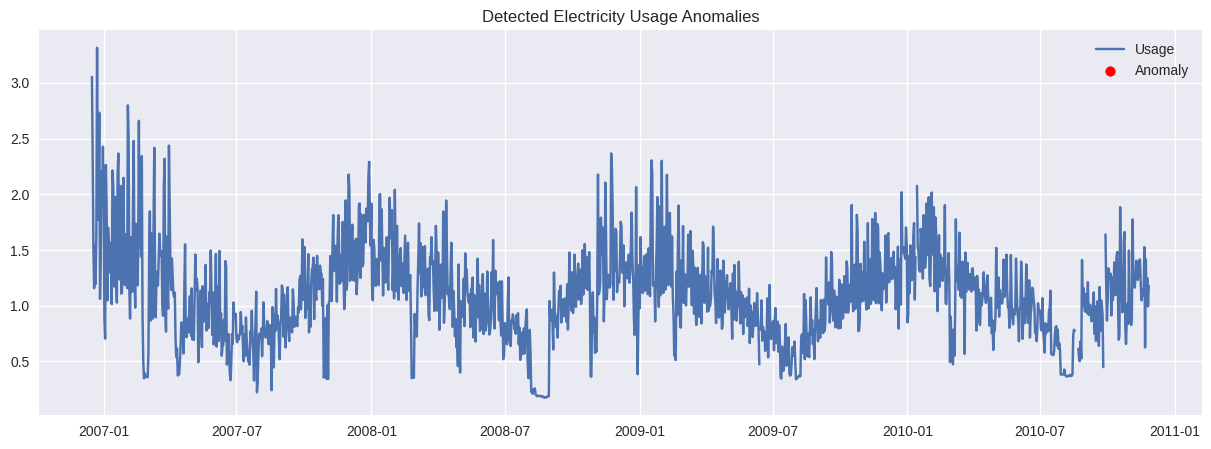

In [10]:
plt.figure(figsize=(15,5))
plt.plot(df["datetime"], df["Global_active_power"], label="Usage")

plt.scatter(
    df[df["anomaly"]]["datetime"],
    df[df["anomaly"]]["Global_active_power"],
    color="red",
    label="Anomaly"
)

plt.legend()
plt.title("Detected Electricity Usage Anomalies")
plt.show()

In [11]:
df[df["anomaly"]].head()

,datetime,Global_active_power,trend_30,day_of_week,rolling_mean_7,rolling_std_7,z_score,anomaly


In [12]:
output_path = f"{BASE_PATH}/data/processed/day2_features.csv"
df.to_csv(output_path, index=False)